# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
!pip install gdown

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy
import scipy.stats as stats
import statsmodels
from statsmodels.stats.proportion import proportions_ztest
import gdown

In [3]:
#mengecek versi library yang digunakan
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Statsmodels version:", statsmodels.__version__)
print("Scipy version:", scipy.__version__)

Pandas version: 2.2.2
Numpy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Statsmodels version: 0.14.6
Scipy version: 1.16.3


### Menyiapkan data yang akan digunakan

In [4]:
# memuat dataset
url = 'https://drive.google.com/file/d/139hYxZvSvB5UntM7-2SP3GnxotrXzMpt/view?usp=sharing'
gdown.download(url, 'employees.csv', quiet=False, fuzzy=True)
jayamaju = pd.read_csv('/content/employees.csv')

Downloading...
From: https://drive.google.com/uc?id=139hYxZvSvB5UntM7-2SP3GnxotrXzMpt
To: /content/employees.csv
100%|██████████| 226k/226k [00:00<00:00, 15.1MB/s]


## Data Understanding

In [5]:
#menampilkan dataset 5 teratas
jayamaju.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [6]:
#mengecek struktur dataset
jayamaju.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [7]:
jayamaju.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeId,1470.0,NaN,NaN,NaN,735.5,424.496761,1.0,368.25,735.5,1102.75,1470.0
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1058.0,NaN,NaN,NaN,0.169187,0.375094,0.0,0.0,0.0,0.0,1.0
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [8]:
#mengecek distribusi nilai attrition termasuk missing value
attrition_distribusi = jayamaju['Attrition'].value_counts(dropna=False)
attrition_distribusi

,count
Attrition,
0.0,879
NaN,412
1.0,179


In [9]:
#mengecek missing value
missing_value = jayamaju.isnull().sum()
missing_value[missing_value > 0]

,0
Attrition,412


In [10]:
jayamaju_afterdropped = jayamaju.dropna(subset=['Attrition']).copy()

In [11]:
#mengecek ulang missing value
missing_value = jayamaju_afterdropped.isnull().sum()
missing_value[missing_value > 0]

,0


In [12]:
#mengecek duplicated
jayamaju_afterdropped.duplicated().sum()

np.int64(0)


Frekuensi Kategori untuk kolom 'BusinessTravel':
                   Jumlah sampel
BusinessTravel                  
Travel_Rarely                746
Travel_Frequently            205
Non-Travel                   107


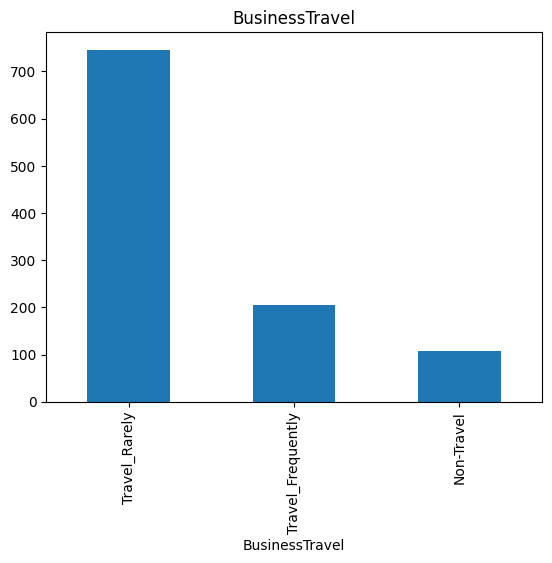


Frekuensi Kategori untuk kolom 'Department':
                        Jumlah sampel
Department                           
Research & Development            701
Sales                             319
Human Resources                    38


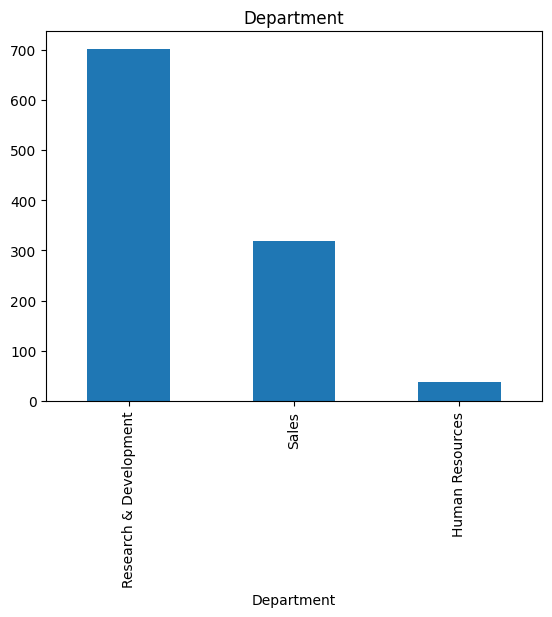


Frekuensi Kategori untuk kolom 'EducationField':
                  Jumlah sampel
EducationField                 
Life Sciences               436
Medical                     330
Marketing                   122
Technical Degree             96
Other                        59
Human Resources              15


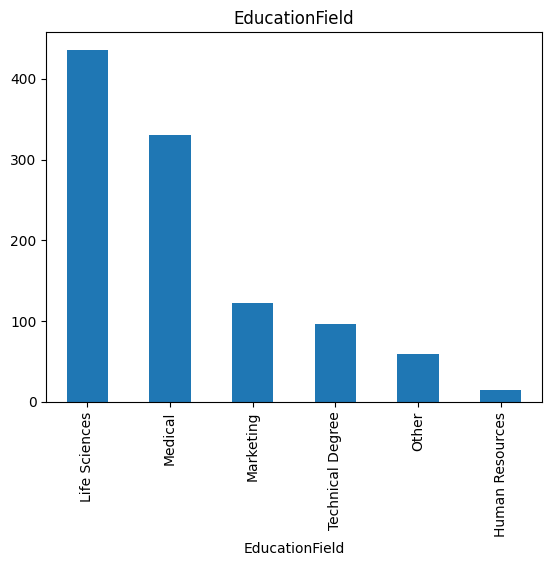


Frekuensi Kategori untuk kolom 'Gender':
        Jumlah sampel
Gender               
Male              620
Female            438


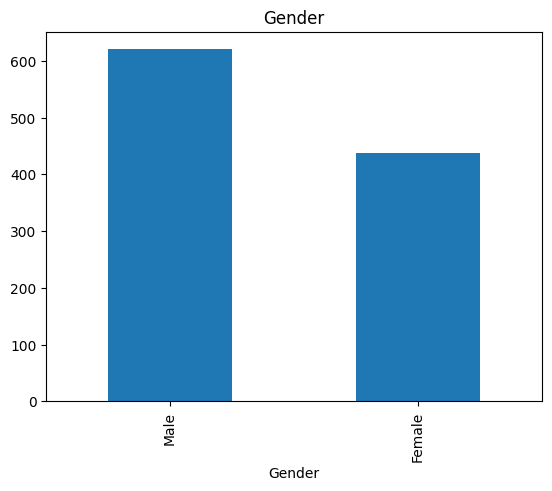


Frekuensi Kategori untuk kolom 'JobRole':
                           Jumlah sampel
JobRole                                 
Sales Executive                      232
Research Scientist                   214
Laboratory Technician                188
Manufacturing Director               107
Healthcare Representative             88
Manager                               79
Research Director                     62
Sales Representative                  58
Human Resources                       30


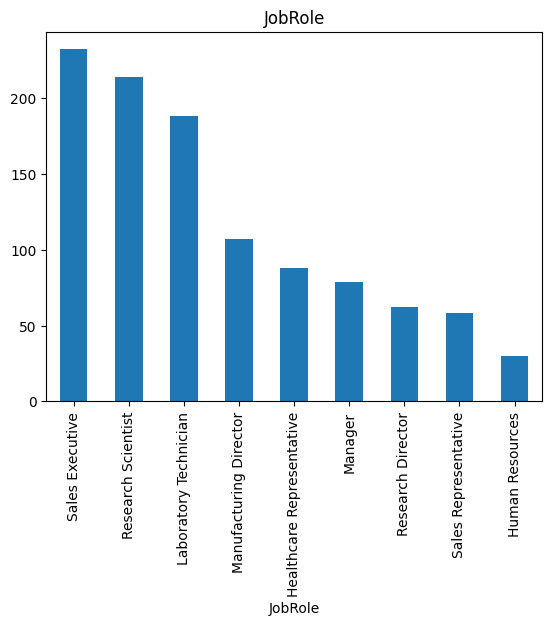


Frekuensi Kategori untuk kolom 'MaritalStatus':
               Jumlah sampel
MaritalStatus               
Married                  464
Single                   352
Divorced                 242


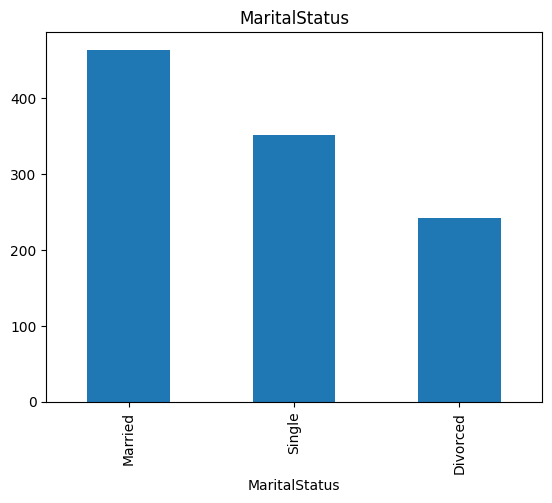


Frekuensi Kategori untuk kolom 'Over18':
        Jumlah sampel
Over18               
Y                1058


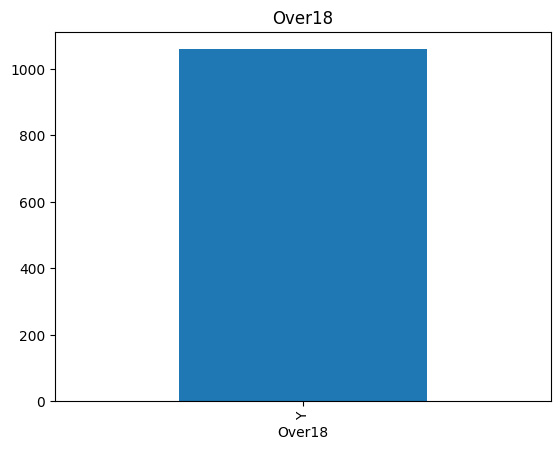


Frekuensi Kategori untuk kolom 'OverTime':
          Jumlah sampel
OverTime               
No                  751
Yes                 307


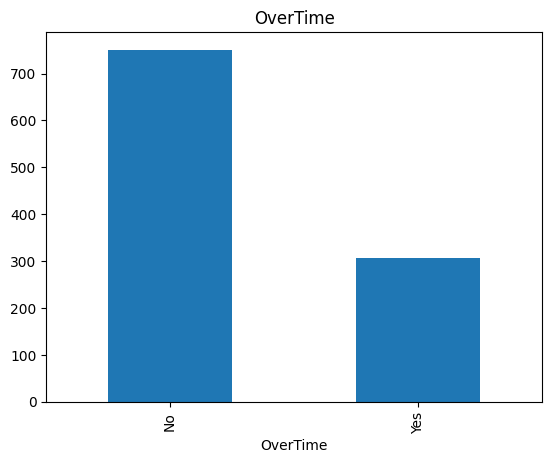

In [13]:
#membuat variabel yang berisi kolom kategori
categorical_fitur = jayamaju_afterdropped.select_dtypes(exclude=np.number).columns

#loop untuk setiap kolom kategorikal
for column in categorical_fitur:
    #menghitung frekuensi kategori untuk kolom saat ini
    counts = jayamaju_afterdropped[column].value_counts()
    #membuat DataFrame untuk kolom saat ini
    df_fitur_kategori = pd.DataFrame({'Jumlah sampel':counts})
    #menampilkan DataFrame untuk kolom
    print(f"\nFrekuensi Kategori untuk kolom '{column}':")
    print(df_fitur_kategori)
    #membuat dan menampilkan plot batang
    jayamaju_afterdropped[column].value_counts().plot(kind='bar', title=column)
    plt.show()

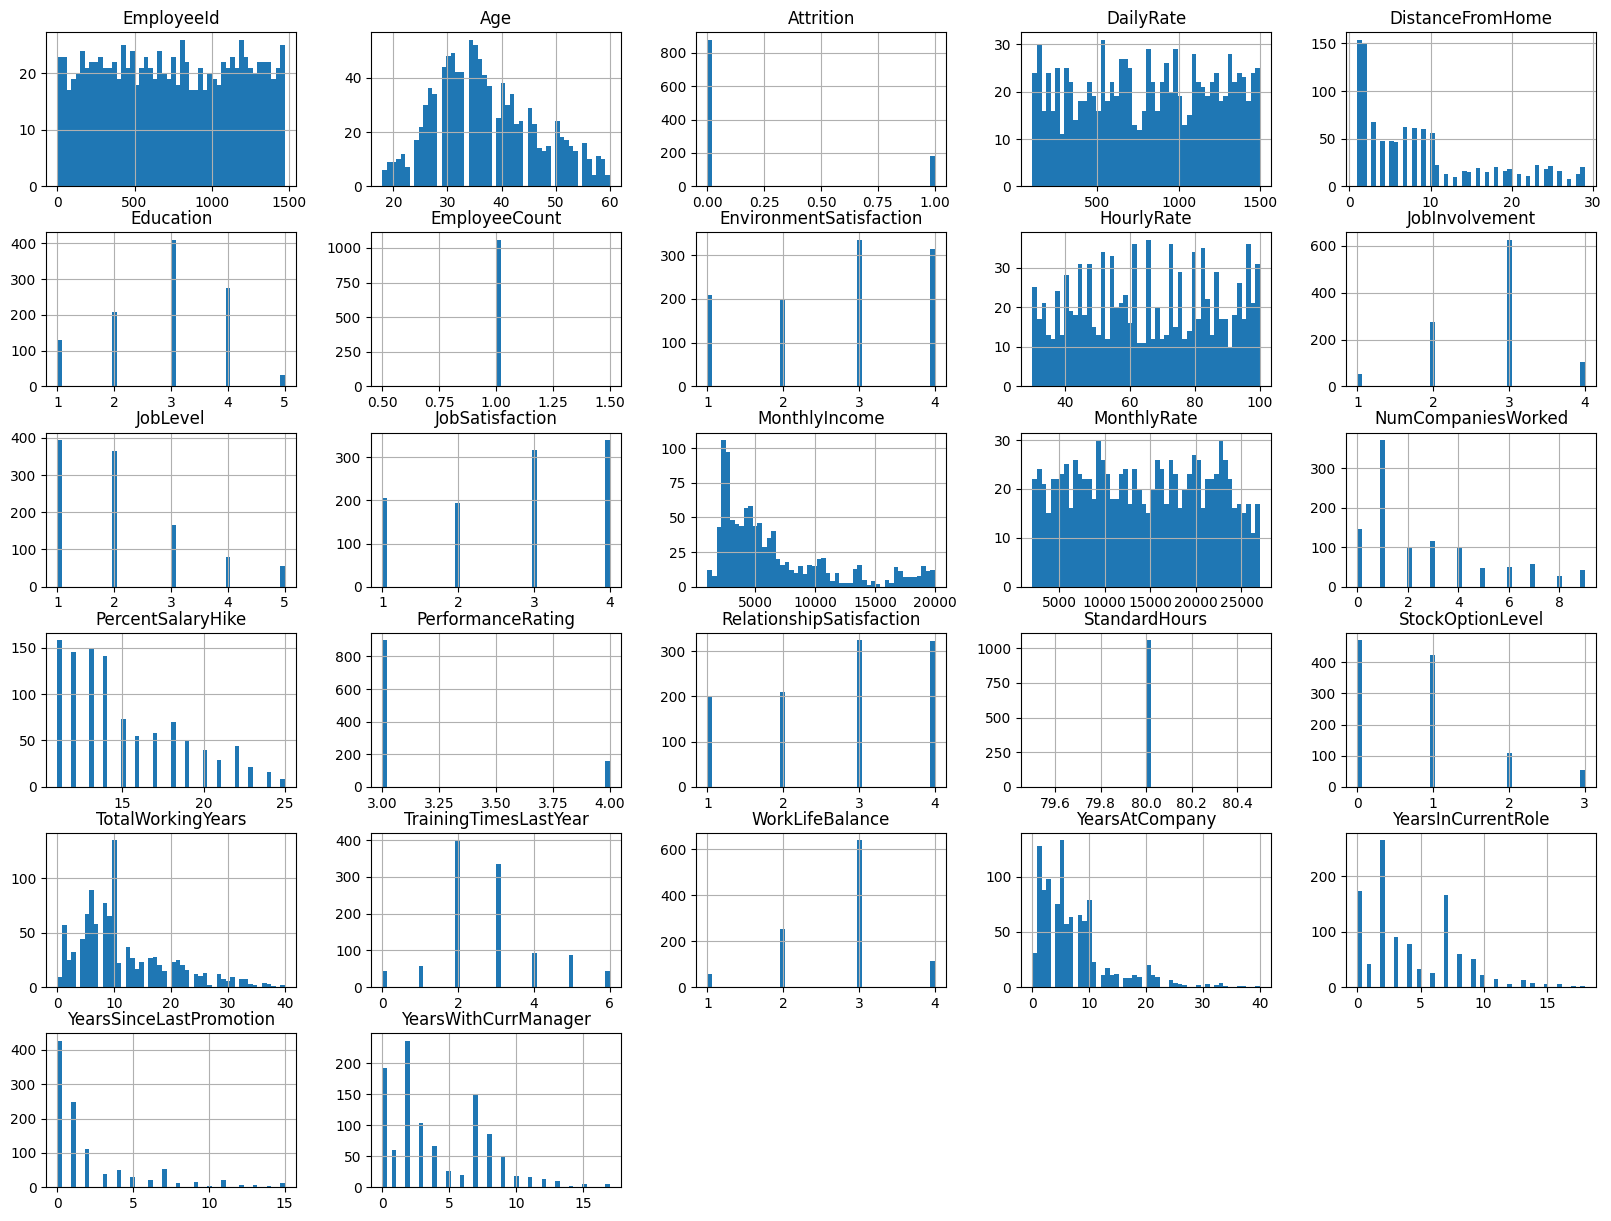

In [14]:
#membuat variabel untuk kolom numerikal fitur
numerical_fitur = jayamaju_afterdropped.select_dtypes(include=np.number).columns
jayamaju_afterdropped.hist(bins=50, figsize=(20,15))
plt.show()

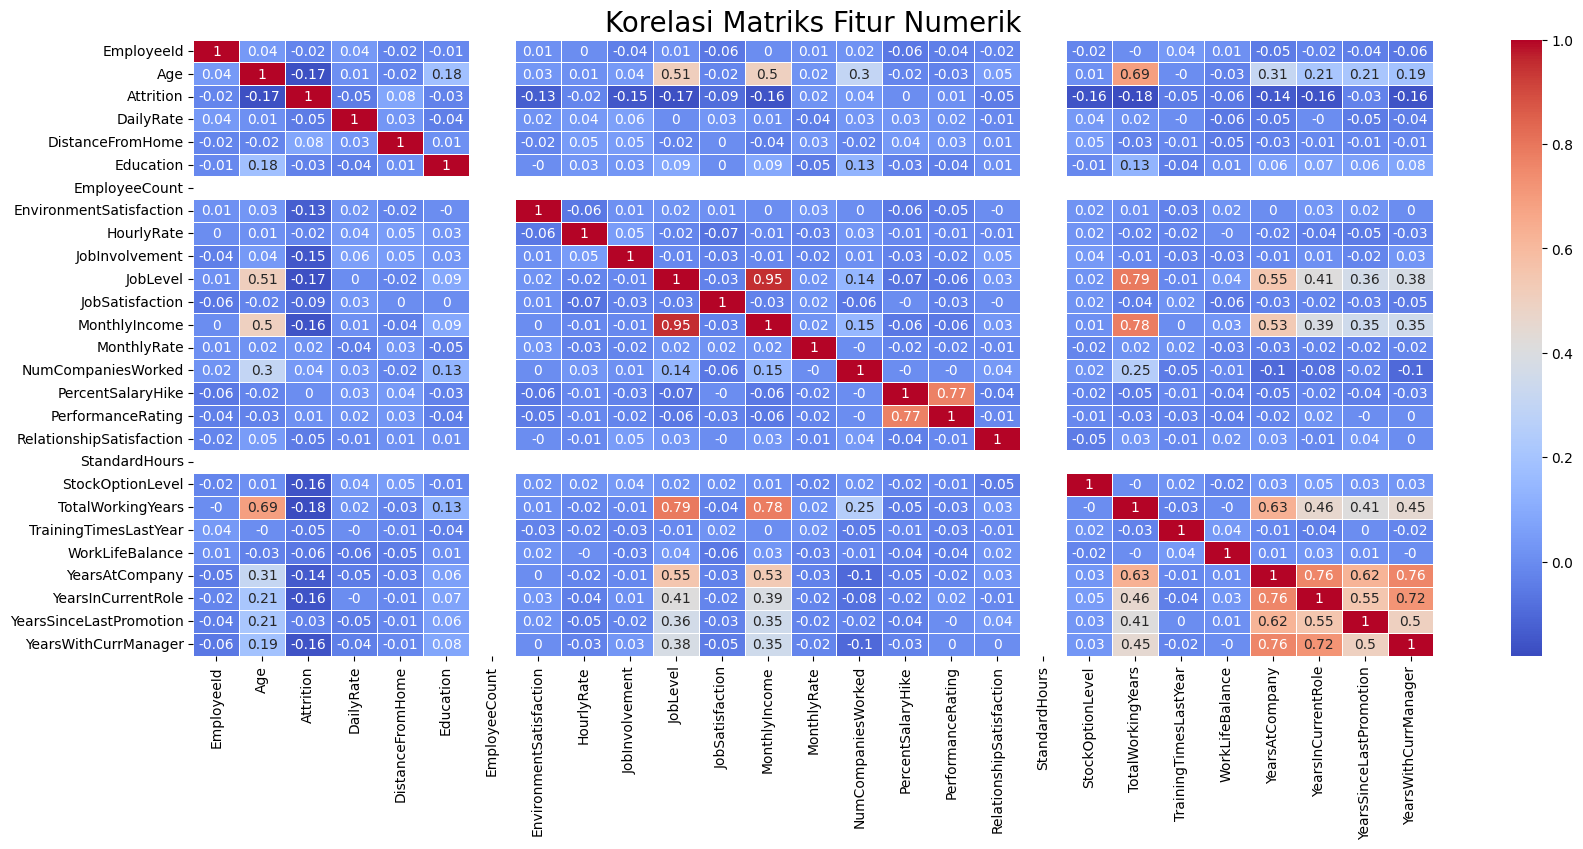

In [15]:
 #korelasi matriks untuk fitur numerik
correlation_matrix = jayamaju_afterdropped[numerical_fitur].corr().round(2)
#membuat visualisasi
plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korelasi Matriks Fitur Numerik', size=20)
plt.show()

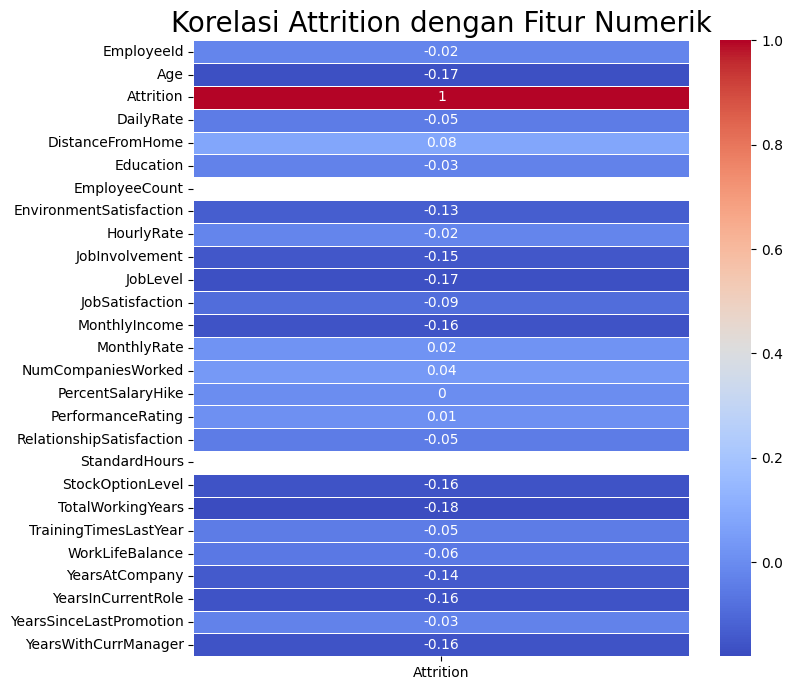

In [16]:
#mengidentifikasi korelasi attrition dengan variabel numerik
#fitur_numerik = jayamaju_afterdropped.select_dtypes(include=np.number).columns
plt.figure(figsize=(8, 8))
correlation_matrix = jayamaju_afterdropped[numerical_fitur].corr().round(2)
attrition_corr =  correlation_matrix['Attrition'].to_frame()
sns.heatmap(attrition_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korelasi Attrition dengan Fitur Numerik', size=20)
plt.show()

/tmp/ipython-input-567/854178620.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


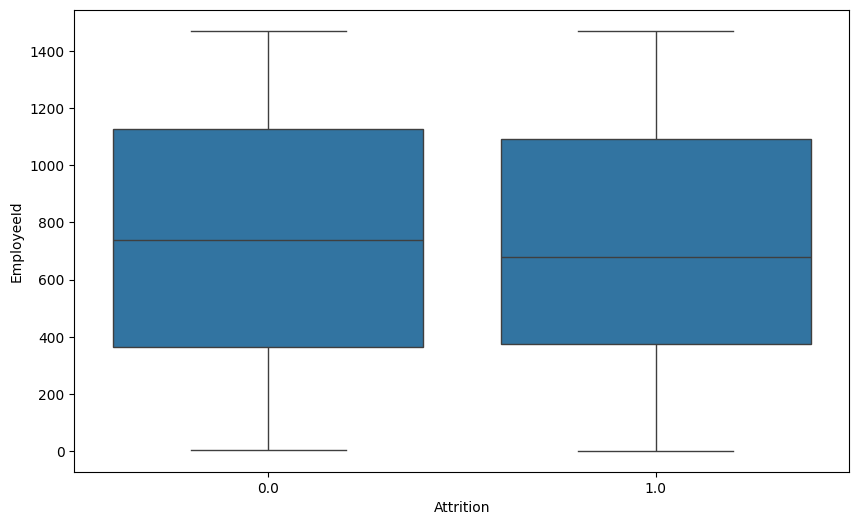

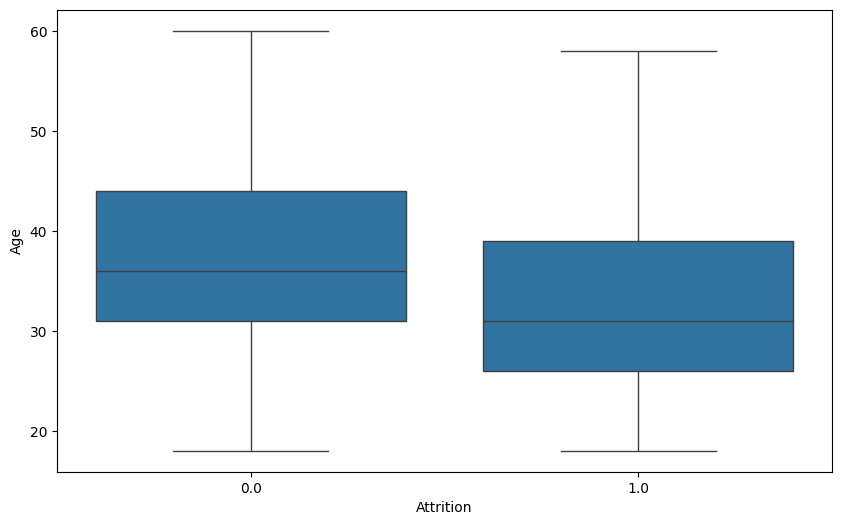

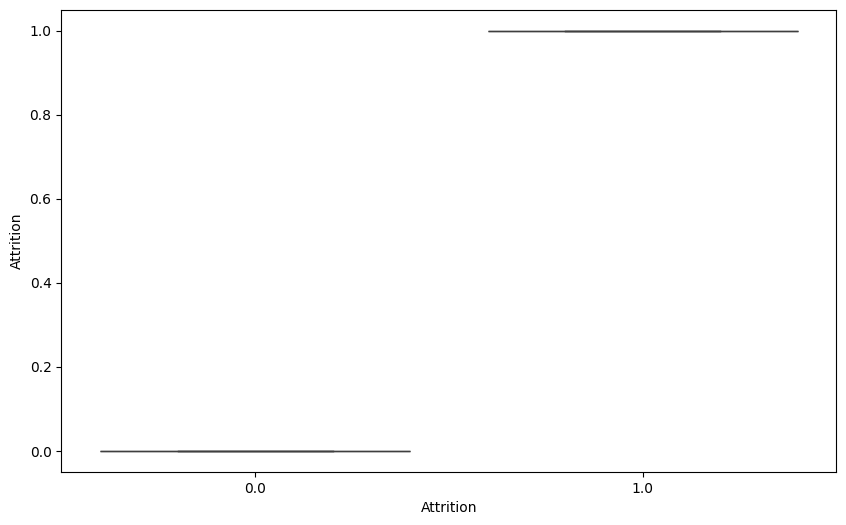

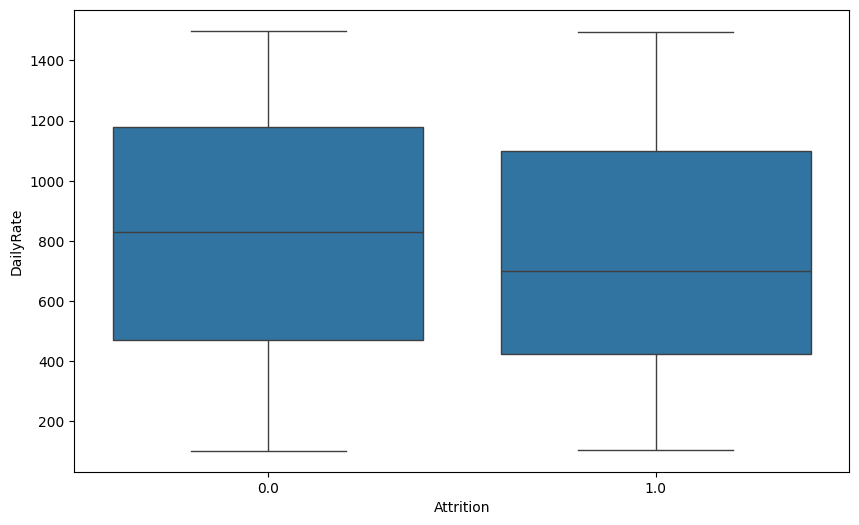

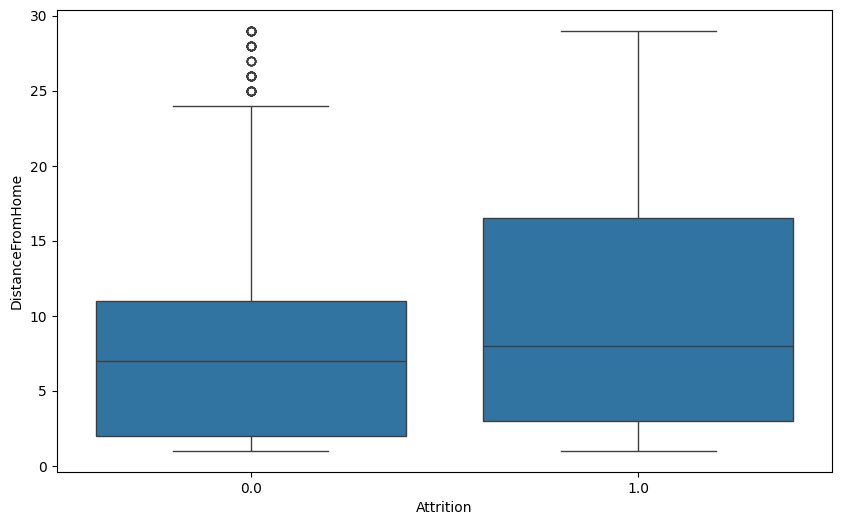

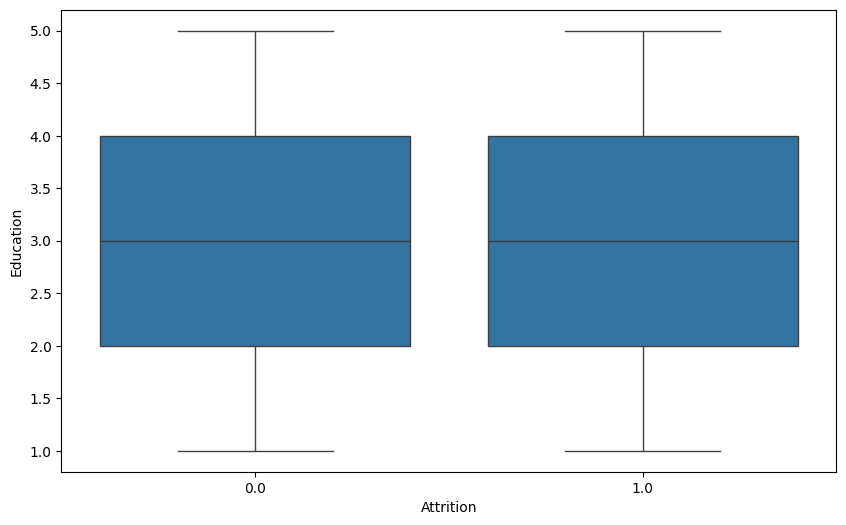

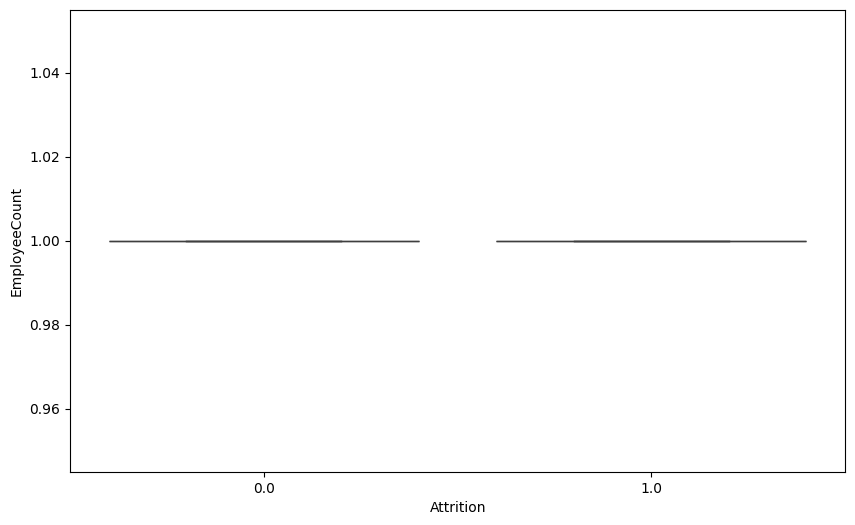

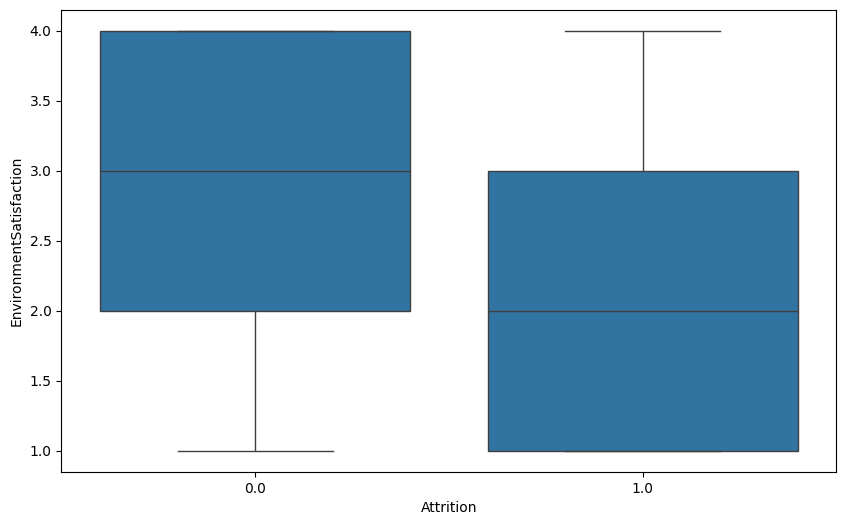

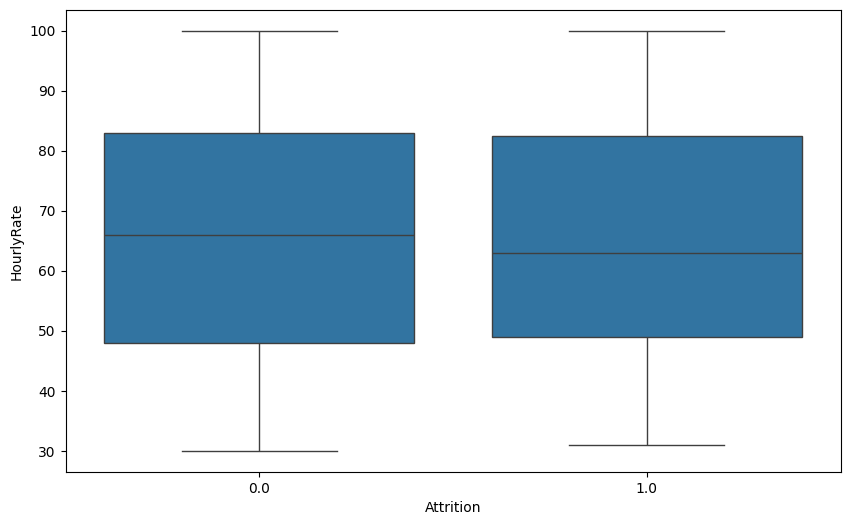

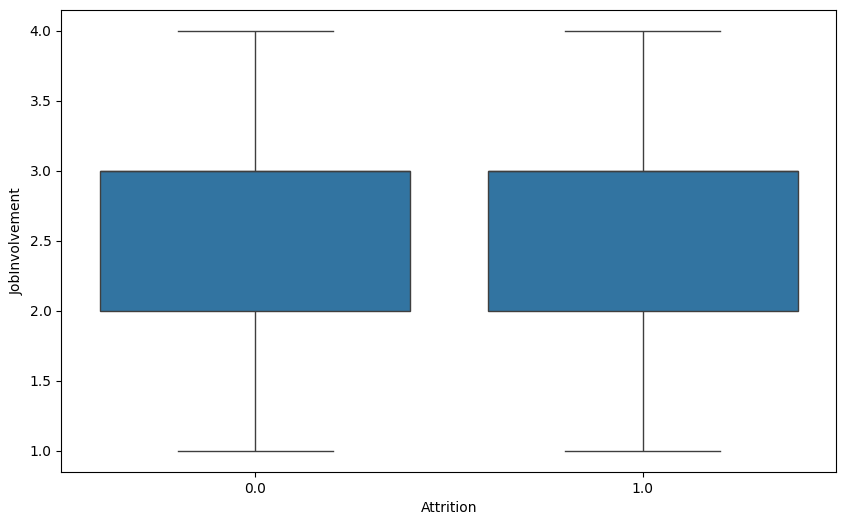

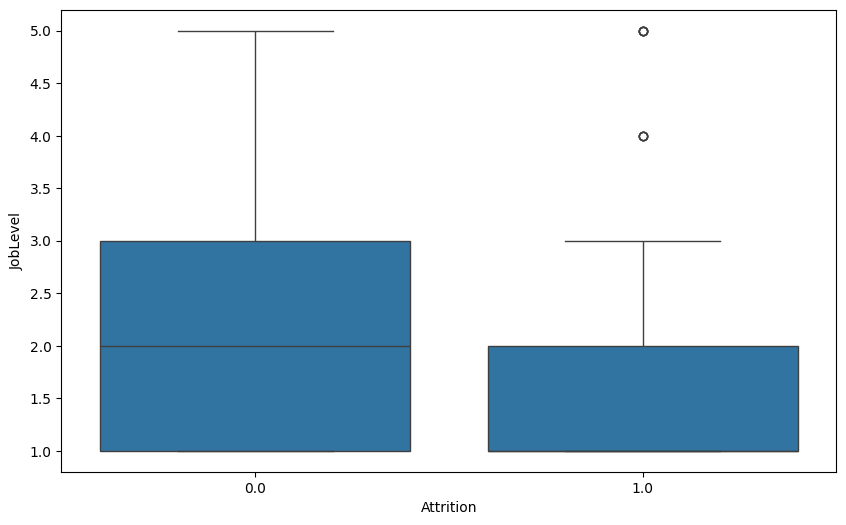

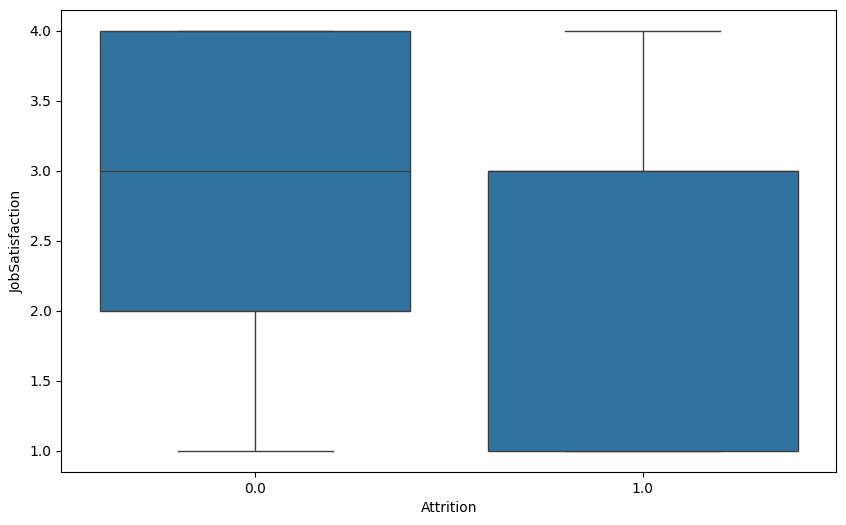

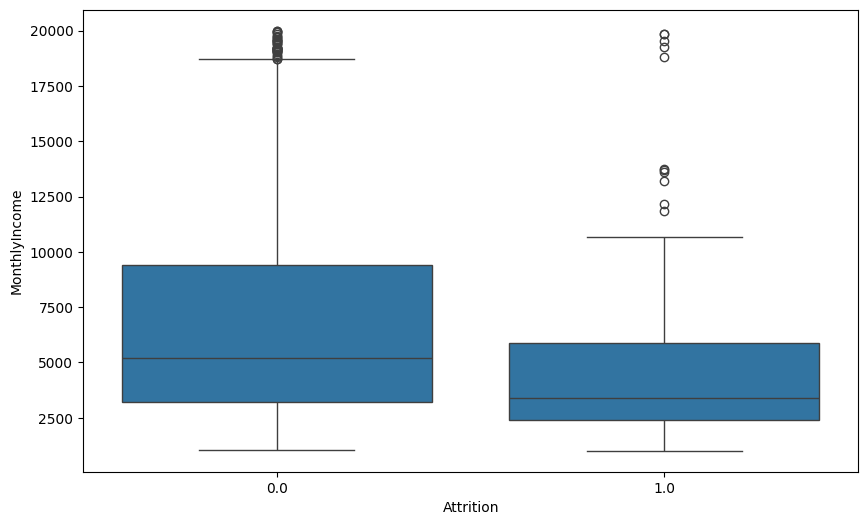

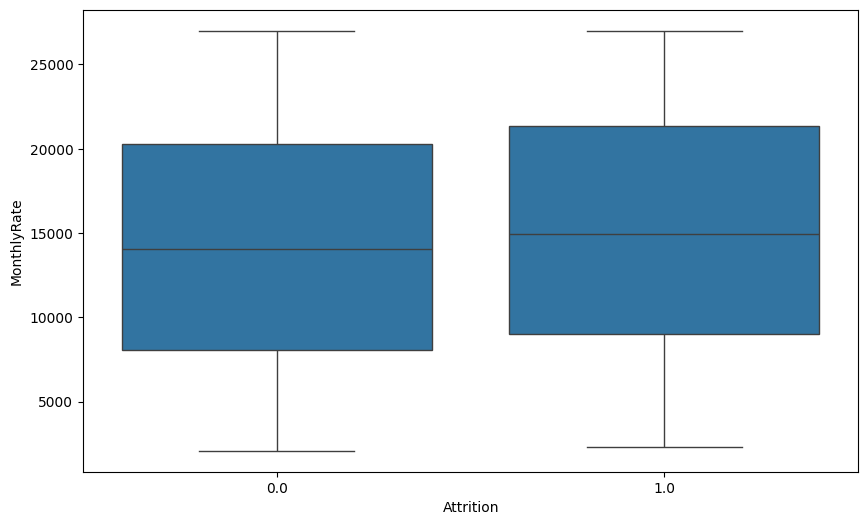

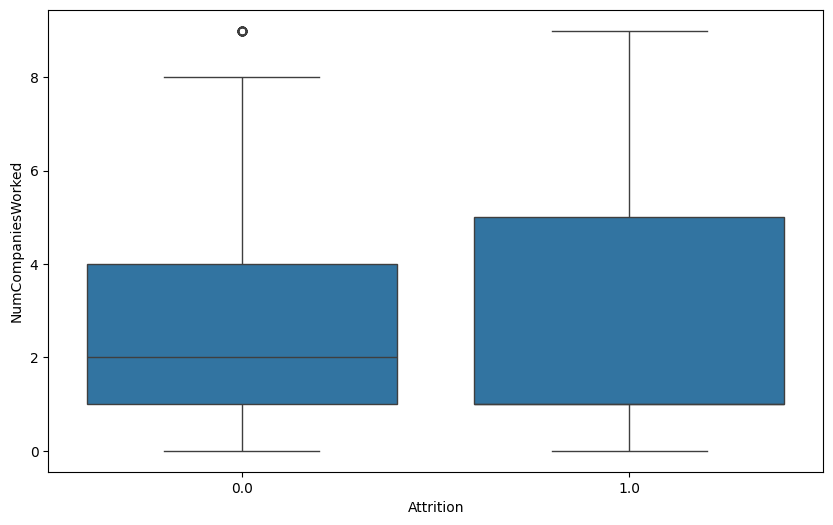

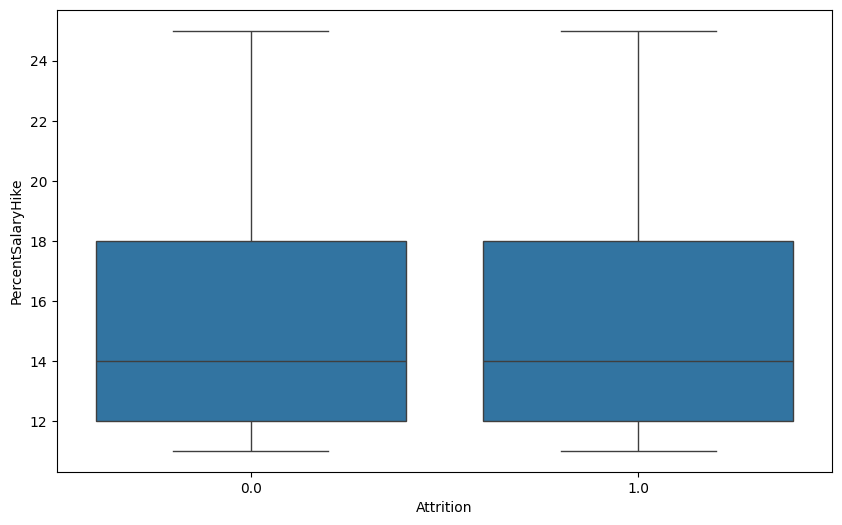

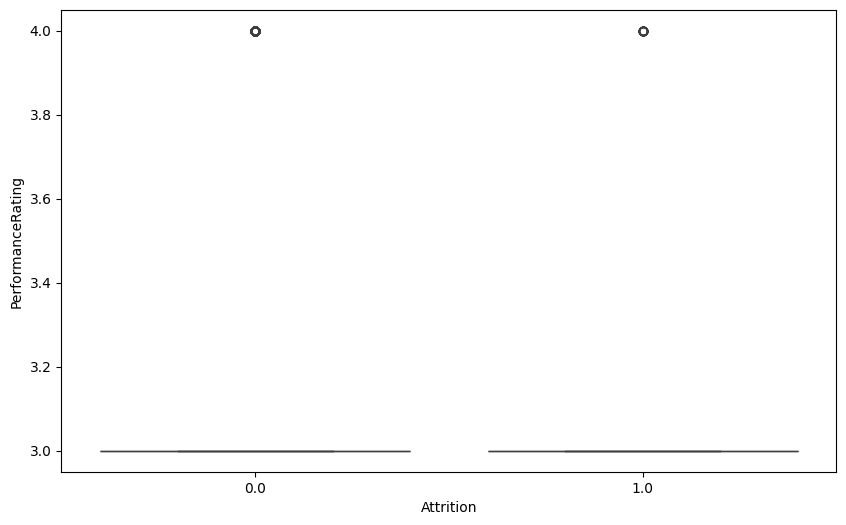

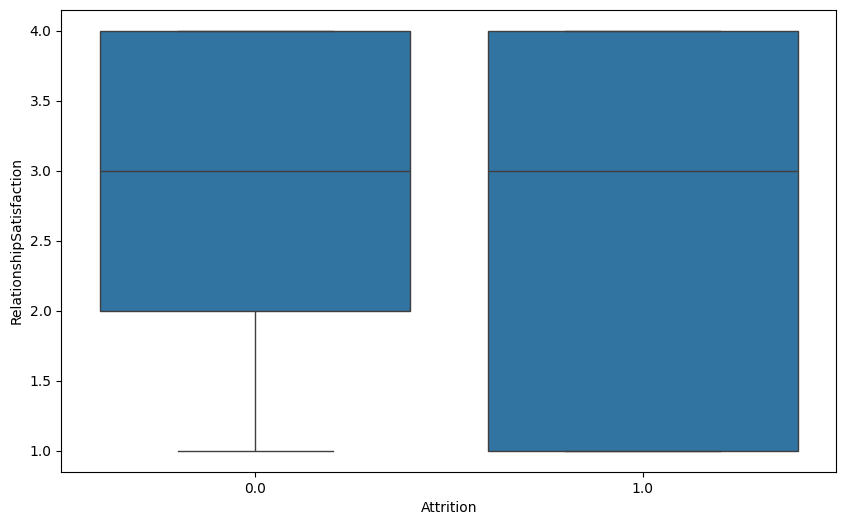

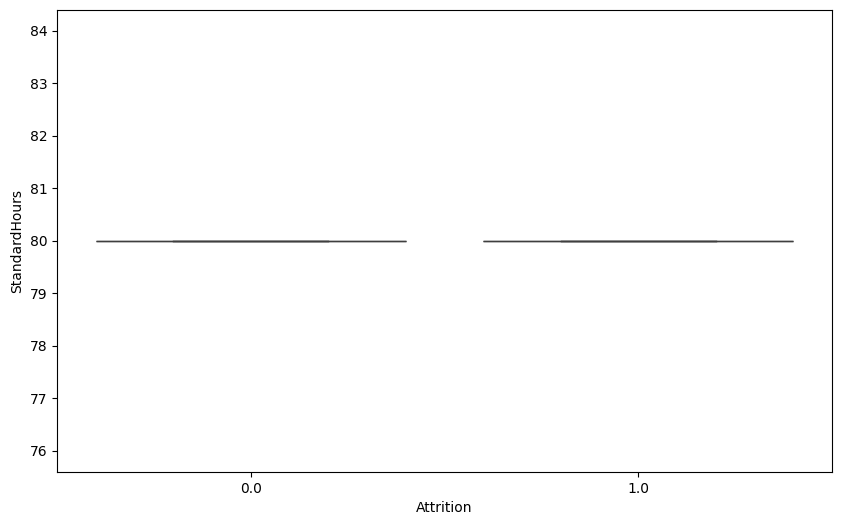

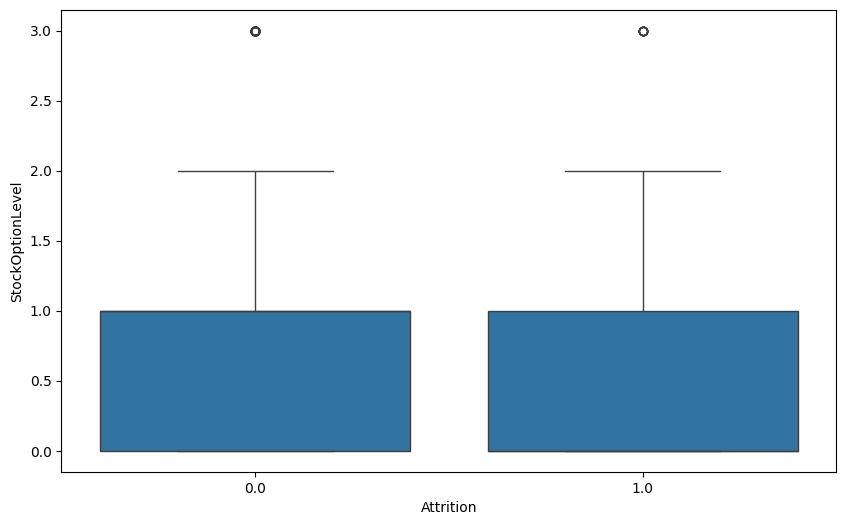

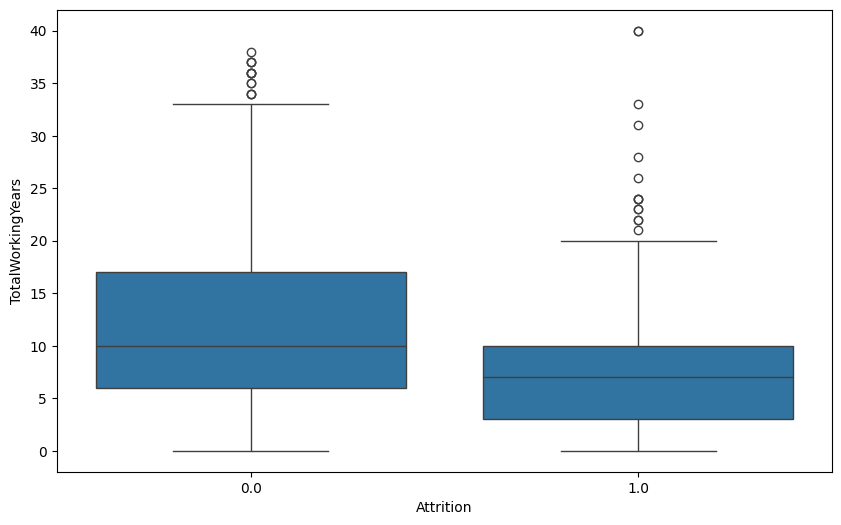

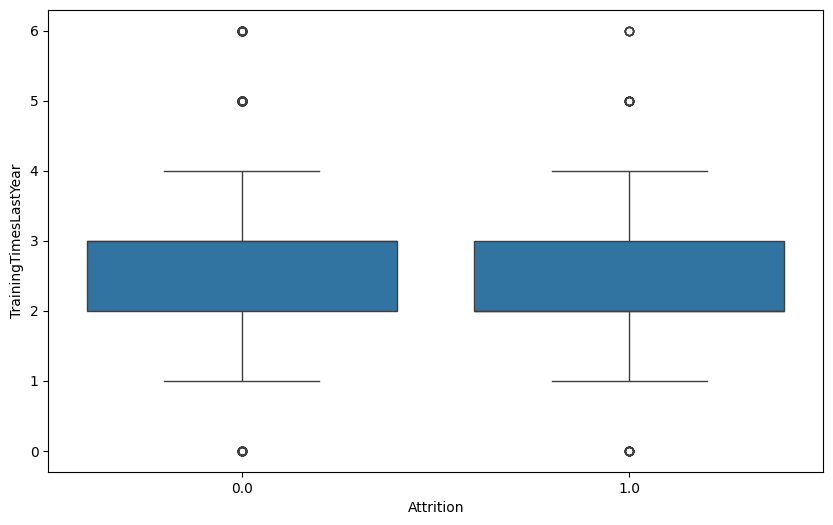

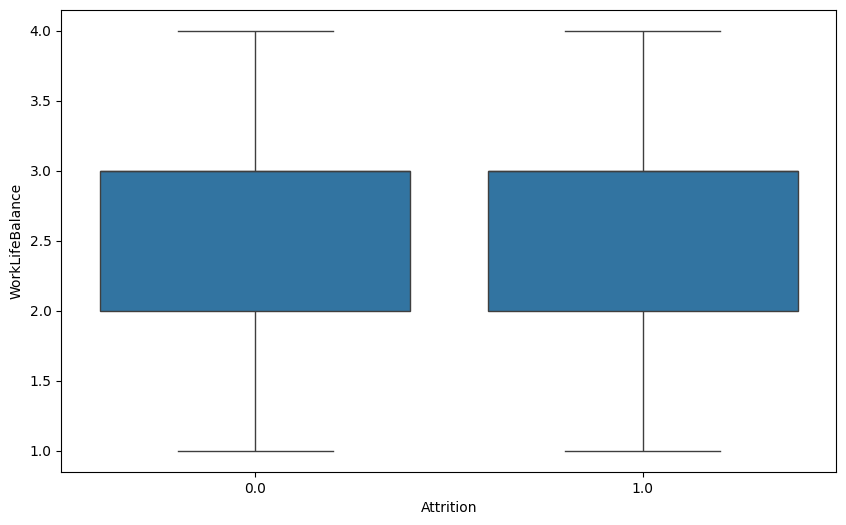

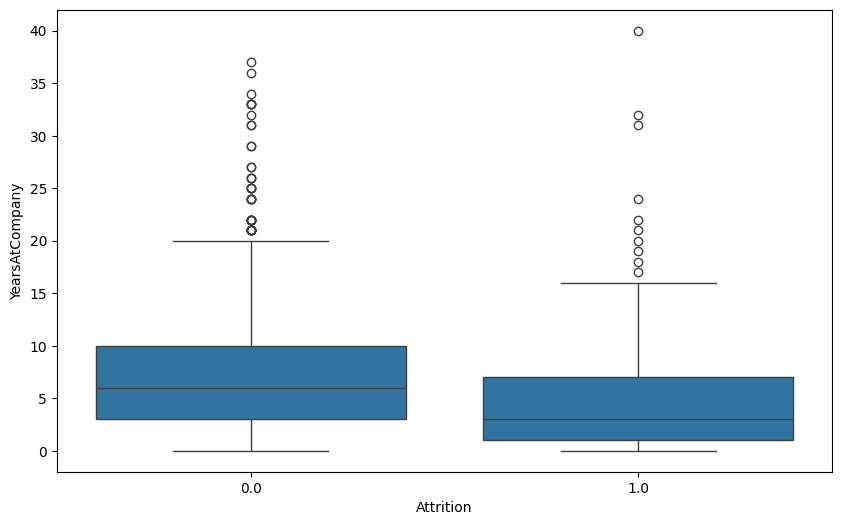

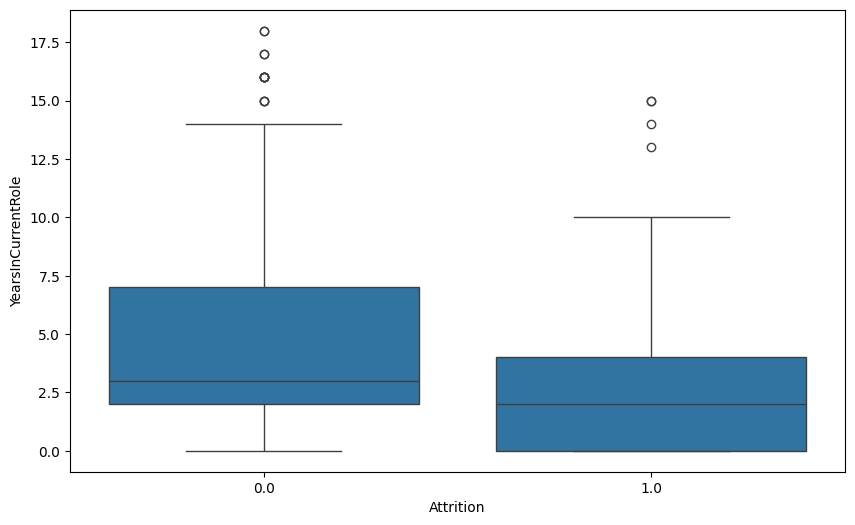

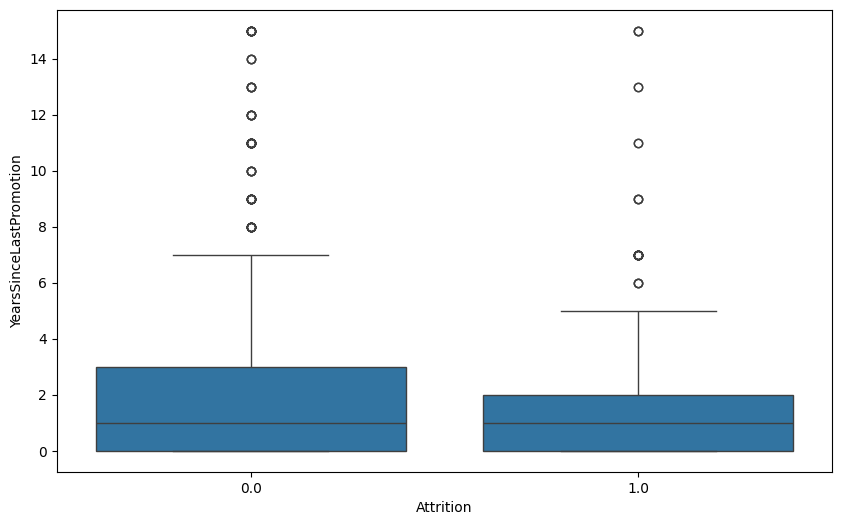

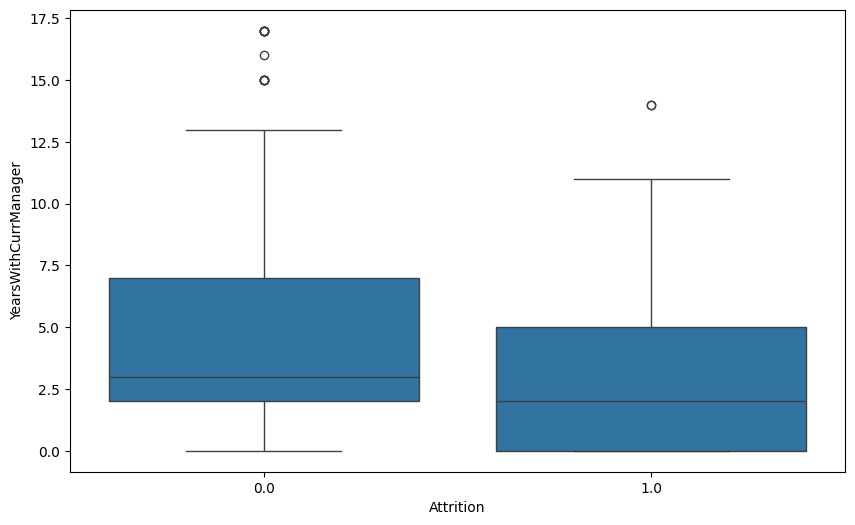

In [17]:
#visualisasi atrittion dengan numerik
for var in numerical_fitur:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Attrition', y=var, data=jayamaju_afterdropped)

### Mengidentifikasi Faktor-faktor yang mempengaruhi Attrition Rate

In [18]:
#uji normalitas
import scipy.stats as stats

# Pisahkan data berdasarkan kelompok Attrition
attrition_0 = jayamaju_afterdropped[jayamaju_afterdropped['Attrition'] == 0]
attrition_1 = jayamaju_afterdropped[jayamaju_afterdropped['Attrition'] == 1]

# Variabel numerik
fitur_numerik = [
    'Age',
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany',
     'YearsInCurrentRole',
     'YearsWithCurrManager',
     'JobSatisfaction',
     'EnvironmentSatisfaction',
     'WorkLifeBalance',
     'JobLevel',
     'StockOptionLevel',
      'DistanceFromHome',
      'NumCompaniesWorked',
      'MonthlyRate',
      'JobInvolvement'
]

# Hasil uji statistik
results = {}

for var in fitur_numerik:
    # uji normalitas
    stat, p_value_normal_0 = stats.shapiro(attrition_0[var])
    stat, p_value_normal_1 = stats.shapiro(attrition_1[var])

    if p_value_normal_0 > 0.05 and p_value_normal_1 > 0.05:
        #data normal, gunakan t-test
        stat, p_value = stats.ttest_ind(attrition_0[var], attrition_1[var])
        test_type = 't-test'
    else:
        #data tidak normal, gunakan Mann-Whitney U Test
        stat, p_value = stats.mannwhitneyu(attrition_0[var], attrition_1[var])
        test_type = 'Mann-Whitney U Test'

    results[var] = {
        'Test Type': test_type,
        'p-value': p_value
    }

#mampilkan hasil
for var, result in results.items():
    print(f"{var}: {result}")


Age: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(3.521775948304546e-09)}
MonthlyIncome: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(9.639440684839486e-11)}
TotalWorkingYears: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(1.1278243635358357e-11)}
YearsAtCompany: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(6.989169589294314e-10)}
YearsInCurrentRole: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(1.040432930748937e-08)}
YearsWithCurrManager: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(2.6796345036999595e-08)}
JobSatisfaction: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(0.0021477648158517238)}
EnvironmentSatisfaction: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(3.8028486251714785e-05)}
WorkLifeBalance: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(0.11487230080111671)}
JobLevel: {'Test Type': 'Mann-Whitney U Test', 'p-value': np.float64(4.482822542265703e-10)}
Sto

### Mengidentifikasi hubungan Attrition dengan variabel kategorik

In [19]:
from scipy.stats import chi2_contingency

#variabel kategorik
variabel_kategorik = [
    'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'Over18'
]

#hasil uji chi-square
hasil_chi_square = {}

for var in variabel_kategorik:
    #membuat tabel kontingensi
    kontingensi = pd.crosstab(jayamaju_afterdropped[var], jayamaju_afterdropped['Attrition'])

    # uji chi-square
    stat, p_value, dof, expected = chi2_contingency(kontingensi)

    #simpan hasil
    hasil_chi_square[var] = {
        'p-value': p_value,
        'Chi2 Stat': stat
    }

#menampilkan hasil
for var, result in hasil_chi_square.items():
    print(f"{var}: {result}")

BusinessTravel: {'p-value': np.float64(0.0012288529464195839), 'Chi2 Stat': np.float64(13.403348217185123)}
Department: {'p-value': np.float64(0.0989004560487226), 'Chi2 Stat': np.float64(4.627282858307121)}
EducationField: {'p-value': np.float64(0.08075507186979243), 'Chi2 Stat': np.float64(9.811528502510315)}
Gender: {'p-value': np.float64(0.6646359911736867), 'Chi2 Stat': np.float64(0.18794084191256483)}
JobRole: {'p-value': np.float64(2.5566953539954712e-11), 'Chi2 Stat': np.float64(66.39397086451051)}
MaritalStatus: {'p-value': np.float64(6.769584947491623e-09), 'Chi2 Stat': np.float64(37.621652119019885)}
OverTime: {'p-value': np.float64(1.8433423444467514e-16), 'Chi2 Stat': np.float64(67.76345890457695)}
Over18: {'p-value': 1.0, 'Chi2 Stat': 0.0}


In [20]:
# variabel kategorikal signifikan
categorical_vars = ['JobRole', 'MaritalStatus', 'OverTime']

# Loop untuk setiap variabel
for var in categorical_vars:
    # Crosstab untuk variabel dan 'Attrition'
    contingency_table = pd.crosstab(jayamaju_afterdropped[var], jayamaju_afterdropped['Attrition'])

    # Uji Chi-Square
    chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"\nChi-Square Test for {var}: Statistic={chi2_stat}, p-value={p_val}")

    # Jika signifikan, lakukan post-hoc
    if p_val < 0.05:
        print(f"\nPost-Hoc Z-Test for {var}:")
        categories = contingency_table.index
        attrition_labels = contingency_table.columns  # Mendapatkan label kolom secara dinamis

        # Loop untuk setiap pasangan kategori
        for i, cat1 in enumerate(categories):
            for j, cat2 in enumerate(categories):
                if i < j:
                    # Data untuk uji z
                    count = np.array([contingency_table.loc[cat1, attrition_labels[1]],
                                      contingency_table.loc[cat2, attrition_labels[1]]])
                    nobs = np.array([contingency_table.loc[cat1].sum(), contingency_table.loc[cat2].sum()])

                    # Uji z
                    z_stat, p_value = proportions_ztest(count, nobs)
                    print(f"{cat1} vs {cat2}: Z-Stat={z_stat:.3f}, p-value={p_value:.3f}")


Chi-Square Test for JobRole: Statistic=66.39397086451051, p-value=2.5566953539954712e-11

Post-Hoc Z-Test for JobRole:
Healthcare Representative vs Human Resources: Z-Stat=-1.596, p-value=0.111
Healthcare Representative vs Laboratory Technician: Z-Stat=-3.246, p-value=0.001
Healthcare Representative vs Manager: Z-Stat=0.665, p-value=0.506
Healthcare Representative vs Manufacturing Director: Z-Stat=0.665, p-value=0.506
Healthcare Representative vs Research Director: Z-Stat=1.418, p-value=0.156
Healthcare Representative vs Research Scientist: Z-Stat=-1.904, p-value=0.057
Healthcare Representative vs Sales Executive: Z-Stat=-1.742, p-value=0.082
Healthcare Representative vs Sales Representative: Z-Stat=-4.808, p-value=0.000
Human Resources vs Laboratory Technician: Z-Stat=-0.710, p-value=0.478
Human Resources vs Manager: Z-Stat=2.116, p-value=0.034
Human Resources vs Manufacturing Director: Z-Stat=2.223, p-value=0.026
Human Resources vs Research Director: Z-Stat=2.677, p-value=0.007
Huma

In [21]:
# Mengubah isi kategori kolom Attrition menjadi kategorikal (opsi 1: untuk tampilan string)
#jayamaju_afterdropped['Attrition'] = jayamaju_afterdropped['Attrition'].astype('category').cat.rename_categories({0: 'No', 1: 'Yes'})

In [22]:
#mengubah isi kategori kolom Attrition menjadi kategorikal
jayamaju_afterdropped['EnvironmentSatisfaction'] = jayamaju_afterdropped['EnvironmentSatisfaction'].astype('category').cat.rename_categories({1: 'Low', 2: 'Medium', 3: 'High', 4:'Very High'})
#mengubah isi kategori kolom Education
jayamaju_afterdropped['Education'] = jayamaju_afterdropped['Education'].astype('category').cat.rename_categories({1: 'Below College', 2: 'College', 3: 'Bachelor', 4:'Master', 5:'Doctor'})
#mengubah isi kategori kolom JobSatisfaction
jayamaju_afterdropped['JobSatisfaction'] = jayamaju_afterdropped['JobSatisfaction'].astype('category').cat.rename_categories({1: 'Low', 2: 'Medium', 3: 'High', 4:'Very High'})
#mengubah isi kategori kolom JobInvolvement
jayamaju_afterdropped['JobInvolvement'] = jayamaju_afterdropped['JobInvolvement'].astype('category').cat.rename_categories({1: 'Low', 2: 'Medium', 3: 'High', 4:'Very High'})
#mengubah isi kategori kolom PerformanceRating
jayamaju_afterdropped['PerformanceRating'] = jayamaju_afterdropped['PerformanceRating'].astype('category').cat.rename_categories({1: 'Low', 2: 'Good', 3: 'Excellent', 4:'Outstanding'})
#mengubah isi kategori kolom RelationshipSatisfaction
jayamaju_afterdropped['RelationshipSatisfaction'] = jayamaju_afterdropped['RelationshipSatisfaction'].astype('category').cat.rename_categories({1: 'Low', 2: 'Medium', 3: 'High', 4:'Very High'})
#mengubah isi kategori kolom WorkLifeBalance
jayamaju_afterdropped['WorkLifeBalance'] = jayamaju_afterdropped['WorkLifeBalance'].astype('category').cat.rename_categories({1: 'Low', 2: 'Good', 3: 'Excellent', 4:'Outstanding'})

display(jayamaju_afterdropped.head())

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,College,Medical,1,...,Low,80,0,15,2,Low,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,Master,Life Sciences,1,...,High,80,3,18,2,Outstanding,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,Bachelor,Marketing,1,...,Very High,80,1,23,2,Outstanding,20,4,4,8
6,7,40,0.0,Travel_Rarely,1124,Sales,1,College,Medical,1,...,High,80,3,6,2,Good,4,3,0,2
7,8,55,1.0,Travel_Rarely,725,Research & Development,2,Bachelor,Medical,1,...,Very High,80,1,24,2,Excellent,5,2,1,4


In [23]:
jayamaju_afterdropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   EmployeeId                1058 non-null   int64   
 1   Age                       1058 non-null   int64   
 2   Attrition                 1058 non-null   float64 
 3   BusinessTravel            1058 non-null   object  
 4   DailyRate                 1058 non-null   int64   
 5   Department                1058 non-null   object  
 6   DistanceFromHome          1058 non-null   int64   
 7   Education                 1058 non-null   category
 8   EducationField            1058 non-null   object  
 9   EmployeeCount             1058 non-null   int64   
 10  EnvironmentSatisfaction   1058 non-null   category
 11  Gender                    1058 non-null   object  
 12  HourlyRate                1058 non-null   int64   
 13  JobInvolvement            1058 non-null   category
 1

In [24]:
#menyimpan DataFrame
jayamaju_afterdropped.to_csv('jayamaju_afterdropped_df.csv', index=False)

### Visualisasi

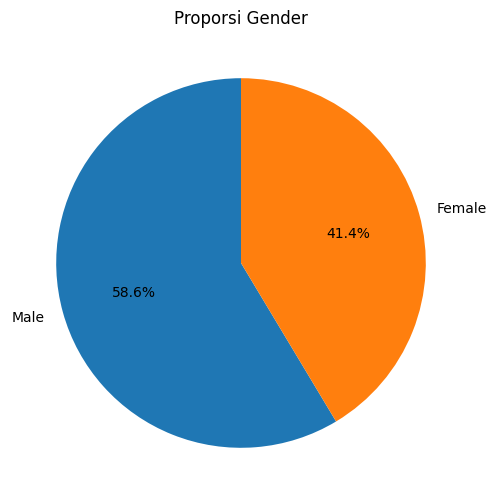

In [25]:
#hitung frekuensi setiap kategori pada kolom gender
gender_counts=jayamaju_afterdropped['Gender'].value_counts()
#visualisasi pie chart untuk proporsi gender
plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%.1f%%', startangle=90)
plt.title('Proporsi Gender')
plt.show()

                     JobRole  Attrition
1  Healthcare Representative        1.0
2         Research Scientist        1.0
3            Sales Executive        0.0
6            Sales Executive        0.0
7                    Manager        1.0


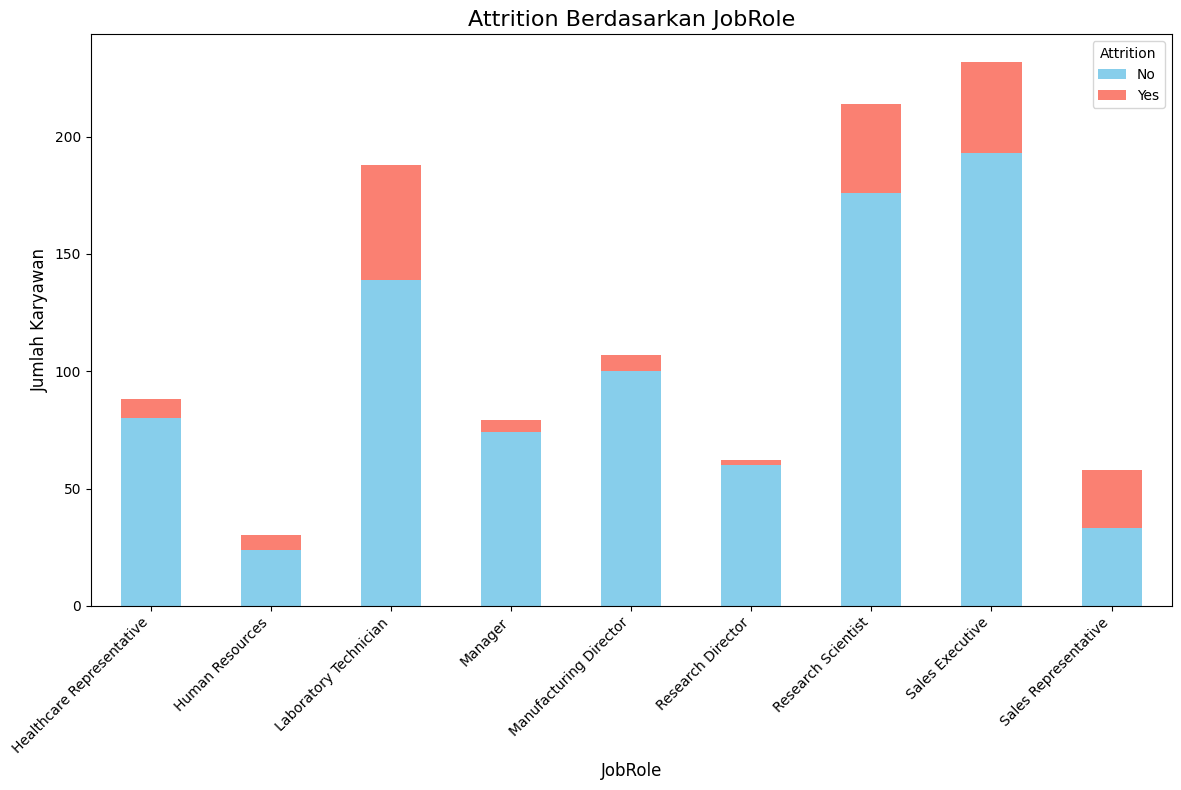

In [26]:
#cetak beberapa data untuk memastikan
print(jayamaju_afterdropped[['JobRole', 'Attrition']].head())

#hitung jumlah karyawan berdasarkan JobRole dan Attrition
jobrole_attrition = jayamaju_afterdropped.groupby(['JobRole', 'Attrition']).size().reset_index(name='EmployeeCount')

#membuat pivot table untuk mempermudah visualisasi
jobrole_pivot = jobrole_attrition.pivot(index='JobRole', columns='Attrition', values='EmployeeCount').fillna(0)

#visualisasi menggunakan stacked bar chart
jobrole_pivot.plot(kind='bar', stacked=True, figsize=(12, 8), color=['skyblue', 'salmon'])

#membuat judul dan label
plt.title('Attrition Berdasarkan JobRole', fontsize=16)
plt.xlabel('JobRole', fontsize=12)
plt.ylabel('Jumlah Karyawan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Attrition', labels=['No', 'Yes'], loc='upper right')
plt.tight_layout()
plt.show()#menampilkan

<Axes: xlabel='OverTime', ylabel='count'>

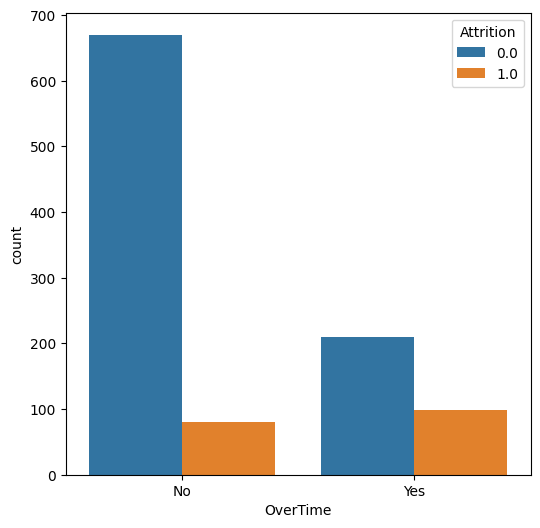

In [27]:
#visualisasi hubungan overtime dengan attrition
plt.figure(figsize=(6,6))
sns.countplot(x='OverTime', hue='Attrition', data=jayamaju_afterdropped)

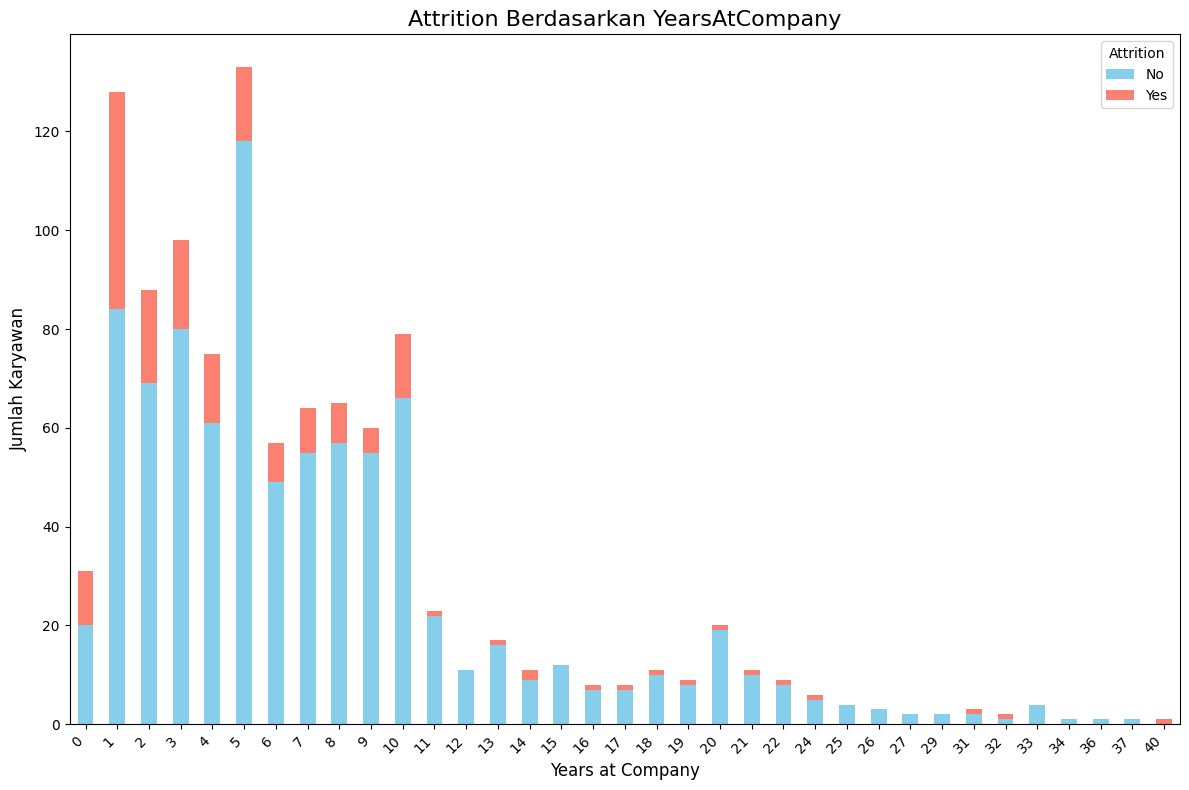

In [28]:
#visualisasi hubungan attrition dengan yearsatcompany dan jumlah karyawan
#hitung jumlah karyawan berdasarkan YearsAtCompany dan Attrition
years_attrition = jayamaju_afterdropped.groupby(['YearsAtCompany', 'Attrition']).size().reset_index(name='EmployeeCount')

#membuat pivot table untuk mempermudah visualisasi
years_pivot = years_attrition.pivot(index='YearsAtCompany', columns='Attrition', values='EmployeeCount').fillna(0)

#visualisasi menggunakan stacked bar chart
years_pivot.plot(kind='bar', stacked=True, figsize=(12, 8), color=['skyblue', 'salmon'])

#tambahkan judul dan label
plt.title('Attrition Berdasarkan YearsAtCompany', fontsize=16)
plt.xlabel('Years at Company', fontsize=12)
plt.ylabel('Jumlah Karyawan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Attrition', labels=['No', 'Yes'], loc='upper right')
plt.tight_layout()
plt.show()#menampilkan



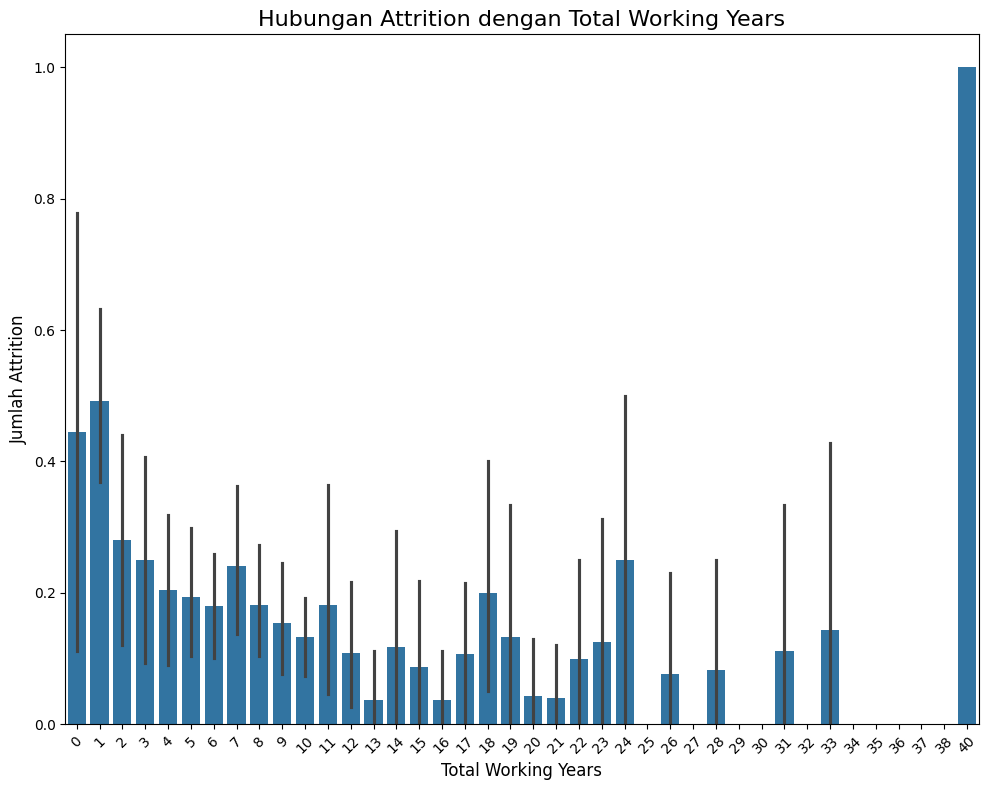

In [29]:
#visualisasi hubungan attrition dengan totalworkingyears
plt.figure(figsize=(10,8))
sns.barplot(x='TotalWorkingYears', y='Attrition', data=jayamaju_afterdropped)
#menambahkan judul dan label
plt.title("Hubungan Attrition dengan Total Working Years", fontsize=16)
plt.xlabel("Total Working Years", fontsize=12)
plt.ylabel("Jumlah Attrition", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
#menampilkan plot
plt.show()

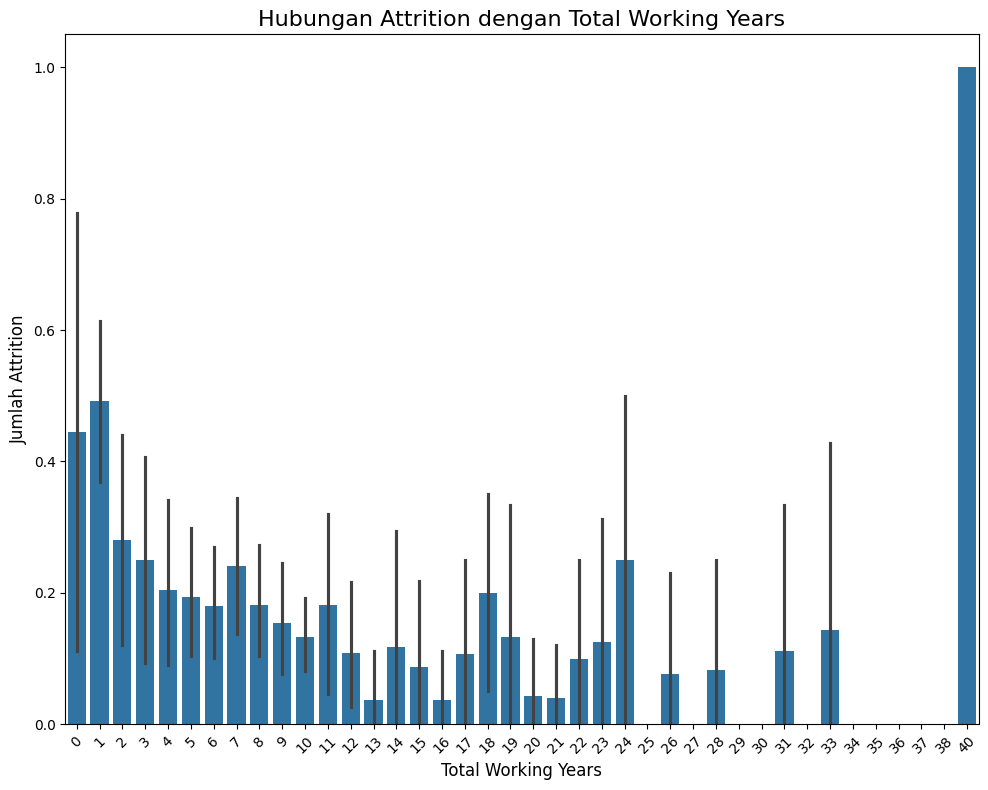

In [30]:
#visualisasi hubungan attrition dengan totalworkingyears
plt.figure(figsize=(10,8))
sns.barplot(x='TotalWorkingYears', y='Attrition', data=jayamaju_afterdropped)
#menambahkan judul dan label
plt.title("Hubungan Attrition dengan Total Working Years", fontsize=16)
plt.xlabel("Total Working Years", fontsize=12)
plt.ylabel("Jumlah Attrition", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
#menampilkan plot
plt.show()

<Axes: xlabel='YearsAtCompany', ylabel='Attrition'>

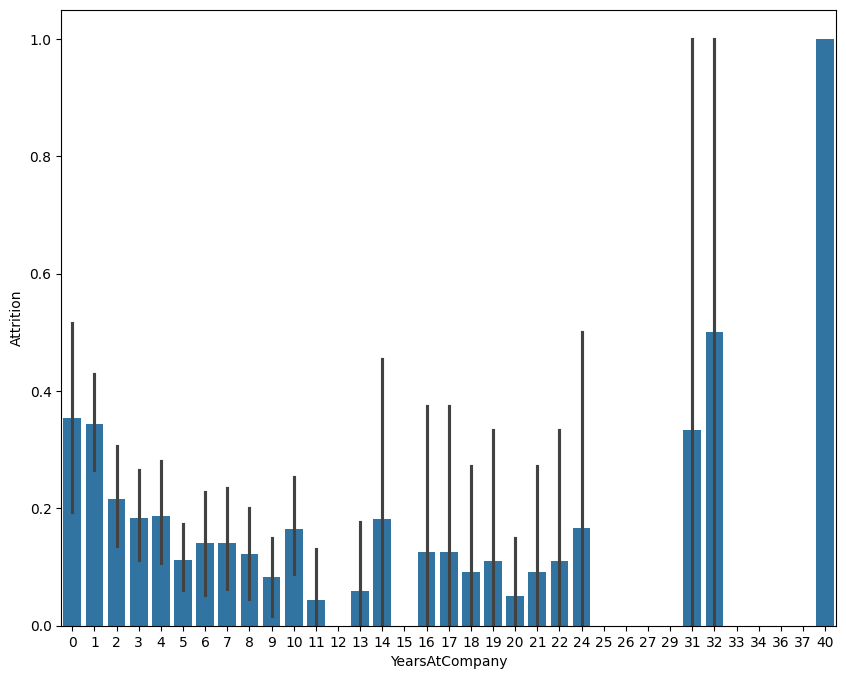

In [31]:
#visualisasi attrition berdasarkan yearsatatcompany
plt.figure(figsize=(10,8))
sns.barplot(x='YearsAtCompany', y='Attrition', data=jayamaju_afterdropped)

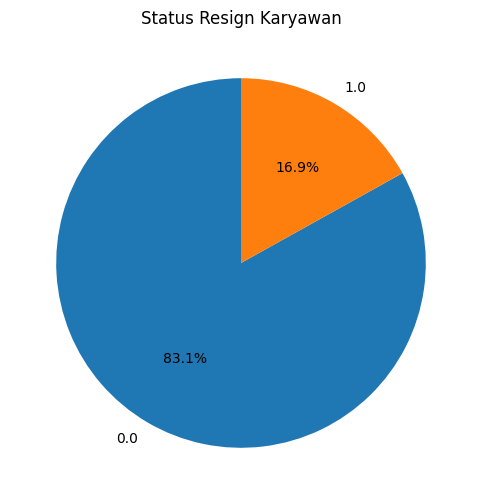

In [32]:
#menghitung attrition
attrition_counts=jayamaju_afterdropped['Attrition'].value_counts()
#visualisasi pie chart untuk proporsi gender
plt.figure(figsize=(6,6))
plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%.1f%%', startangle=90)
plt.title('Status Resign Karyawan')
plt.show()

<Figure size 1000x600 with 0 Axes>

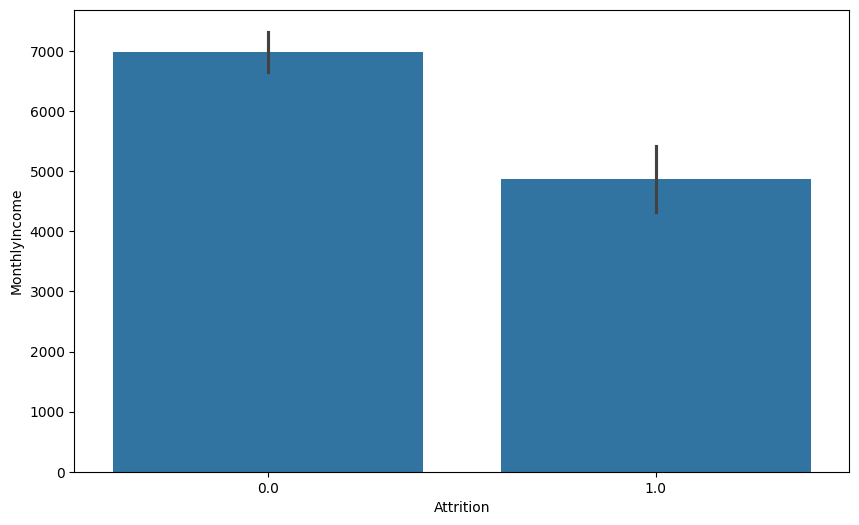

<Figure size 1000x600 with 0 Axes>

In [33]:
#visualisasi hubungan attrition dan monthlyincome
plt.figure(figsize=(10, 6))
sns.barplot(x='Attrition', y='MonthlyIncome', data=jayamaju_afterdropped)
plt.figure(figsize=(10, 6))

In [34]:
pip freeze | grep -E 'seaborn|pandas|numpy|matplotlib|scipy|statsmodels' > requirements.txt